# Bayesian Linear Regression With HMC And NUTS

This notebook uses probabilistic programming and the No-U-Turn Sampler (NUTS) to infer a Bayesian RBF regression model from noisy synthetic data. It builds the model in NumPyro, diagnoses the resulting posterior samples with ArviZ, and compares two ways of producing predictions from the posterior.

The notebook follows the same regression problem as the preceding Monte Carlo study, but replaces hand-tuned Metropolis proposals with Hamiltonian Monte Carlo. NUTS uses gradient information and adapts its trajectory during warm-up, making it much more practical for a correlated, high-dimensional posterior.

**Workflow:**

1. Generate a reproducible data set and baseline RBF fit.
2. Express the regression model as a NumPyro probabilistic program.
3. Run NUTS and inspect posterior diagnostics.
4. Summarise the inferred hyperparameters.
5. Compare plug-in predictions with predictions averaged over posterior samples.

## Context And Reproducibility

The model and synthetic data are generated locally, so no external data download is required. The inference run uses a fixed JAX random key, making the posterior summaries and plots reproducible for the same software environment.

Run the notebook from `Coursework_2/` so that Python can import `setup_cw2.py`.

## Notebook Guide

The narrative introduces the modelling decision before each computational stage. The code remains deliberately visible: the NumPyro model defines the posterior, NUTS performs inference, ArviZ evaluates the chain, and the final cells turn posterior draws into predictive curves.

## Dependencies

The notebook uses NumPy, SciPy, Matplotlib, JAX, NumPyro, ArviZ, and the shared utilities in `setup_cw2.py`. NumPyro is configured for CPU execution. The optional model-rendering cell additionally requires the Graphviz Python package and system executable.

# Probabilistic Regression With NUTS

This study uses Hamiltonian Monte Carlo with the No-U-Turn Sampler to infer the unknown quantities in a Bayesian linear regression model: the prior precision $\alpha$, RBF width $r$, observation noise $\sigma$, and weight vector $\mathbf{w}$.

Unlike a random-walk Metropolis sampler, NUTS uses gradients of the log posterior and automatically adapts its trajectory length during warm-up. That removes much of the manual proposal-scale tuning required by lower-level MCMC implementations, although model parameterisation and prior choice still matter.

## Inference Objective

The single inference run estimates the full posterior of the RBF regression model. The later cells use diagnostics to assess whether the chain has explored the target distribution and then compare a fast plug-in predictor with a posterior-averaged predictor.

## Setup

The setup imports the numerical, probabilistic-programming, and visualisation libraries, configures JAX for CPU execution, and loads the shared data and plotting helpers. The notebook uses JAX arrays inside the NumPyro model because NumPyro traces and differentiates model computations through JAX.

### Additional Libraries

NumPyro provides the probabilistic-programming interface and NUTS implementation, JAX supplies differentiable array operations, and ArviZ provides posterior summaries and diagnostics. The main inference path needs NumPyro, JAX, and ArviZ; Graphviz is required only for the optional model-structure rendering cell.

In [1]:
#
# Setup
#
# Standard modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance  # Needed for RBF

# Modules required for MCMC
import jax
import jax.numpy as jnp  # Use instead of numpy 'np' in numpyro model functions, e.g. RBF
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az

import setup2 as setup

# Change this if you are brave!
jax.config.update('jax_platform_name', 'cpu')
# This next line throws up a pointless unnecessary warning, but suppresses a more annoying one later
print(jax.devices())
# Uncomment if necessary - otherwise, jax defaults to 32-bit
# jax.config.update("jax_enable_x64", True)

print(f"Using version {numpyro.__version__} of numpyro")

# You may see a warning below:
# "An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed."
# This is expected!

c:\Users\cjogi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CpuDevice(id=0)]
Using version 0.21.0 of numpyro


In [2]:
#
# Setup
#
# Define some fixed values
#
# Parameters that determine the generated data
#
sigma = 0.2  # Standard deviation
sigma_2 = sigma ** 2  # Variance
radius_gen = 1.00  # Generative basis radius or width
#
N_train = 50
N_test = 1000



### Generate Data And A Baseline Fit

As before, the generator creates 50 noisy training observations and a dense noiseless test curve over $x\in[0,10]$. The initial RBF fit uses fixed centres and an example width, providing a visual baseline before the probabilistic model learns its unknown parameters.

N_train = 50
Empirical σ_train = 0.200
N_test = 1000


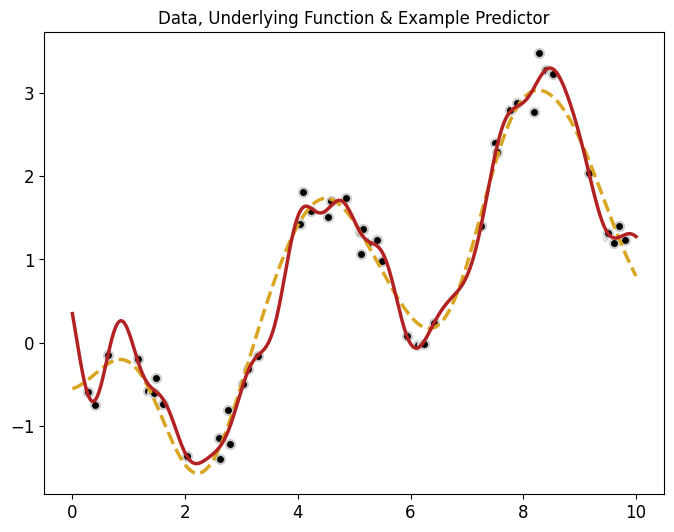

In [3]:
# Generate training data
generator = setup.DataGenerator(r=radius_gen, noise=sigma)
x_train, y_train = generator.get_data('TRAIN', N_train)
x_test, y_test = generator.get_data('TEST', N_test)

# Demonstrate use of basis
centres = np.linspace(generator.x_min, generator.x_max, N_train - 1)
radius_model = radius_gen * 0.5  # Example model uses basis functions that are too narrow
RBF = setup.RBFGenerator(centres, radius_model, bias=True)
PHI_train = RBF.evaluate(x_train)
PHI_test = RBF.evaluate(x_test)

# Find quick fit for fixed guess for alpha and known s2
alph = 1e-3
w_pls = np.linalg.inv(PHI_train.T @ PHI_train + alph * np.eye(RBF.M)) @ PHI_train.T @ y_train
fy_test = PHI_test @ w_pls

# Show the training data and generating function, plus our mean fit
setup.plot_regression(x_train, y_train, x_test, y_test, fy_test)
plt.title("Data, Underlying Function & Example Predictor");

### A JAX-Compatible RBF Basis

NumPyro needs model computations that JAX can trace and differentiate. `JRBFGenerator` keeps the centres fixed but accepts the radius as an argument to `evaluate`, allowing each posterior sample to use its own RBF width. Its array operations are compatible with JAX's automatic differentiation.

In [4]:
#
# Basis class that is JAX compatible
# Centres are fixed for evaluation, but radius is parameterised
#
class JRBFGenerator(object):

    """Generate Jax-compatible Gaussian RBF basis
    with parameterised radius"""

    def __init__(self, loci, bias=False):
        self.M = len(loci)
        self.centres = loci.reshape((self.M, 1))
        self.is_bias = bias
        if bias:
            self.M += 1

    def evaluate(self, X, radius):
        N = len(X)
        d2 = distance.cdist(X, self.centres, metric="sqeuclidean")
        PHI = jnp.exp(-d2 / (radius ** 2))
        if self.is_bias:
            PHI = jnp.hstack((np.ones((N, 1)), PHI))
        #
        return PHI

## Define The Probabilistic Model

The NumPyro model places uniform priors on $\log_{10}\alpha$, $\log_{10}r$, and $\log_{10}\sigma$. These are transformed back to their original positive scales before constructing the design matrix and Gaussian weight prior.

The observed targets follow a Gaussian likelihood with mean $\mathbf{\Phi}\mathbf{w}$ and standard deviation $\sigma$. Calling `numpyro.sample` with `obs=y` conditions this generative model on the training data, defining the posterior that NUTS will explore.

In [5]:
# This can be defined just the once
JRBF = JRBFGenerator(centres, bias=True)

def model(x, y):
    # Declare random variables log alpha, sigma and r, to be sampled froma uniform distribution
    log_alpha = numpyro.sample("log_alpha", dist.Uniform(-6, 4))
    log_r = numpyro.sample("log_r", dist.Uniform(-2, +1))
    log_sigma = numpyro.sample("log_sigma", dist.Uniform(-1, 1))

    # Convert back to original scales
    alpha = 10 ** log_alpha
    r = 10 ** log_r
    sigma = 10 ** log_sigma
    sigma_2 = sigma ** 2


    PHI = JRBF.evaluate(x, radius=r)

    # Define the prior over the weights w
    # Declare random variable w to be sampled from a normal distribution with mean 0 and sd 1/sqrt(alpha)
    w = numpyro.sample("w", dist.Normal(0, 1/jnp.sqrt(alpha)).expand([PHI.shape[1]]))
    
    y = y.flatten()


    mu = jnp.dot(PHI, w)
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


### Optional Model Graph

Rendering the probabilistic graph is a useful structural check: it makes the dependency from hyperparameters to weights, basis functions, and observations explicit. This visualisation is optional because it depends on the external Graphviz executable, but it does not affect inference.

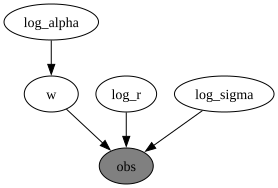

In [6]:
from numpyro import render_model

numpyro.render_model(model, model_args=(x_train, y_train))


## Run NUTS

NUTS is run with 500 warm-up iterations followed by 1,000 posterior draws. During warm-up it adapts the step size and mass matrix, reducing the need to hand-tune a proposal distribution.

The built-in summary reports posterior means, uncertainty, effective sample sizes, and convergence diagnostics such as $\hat{R}$. A healthy run should have no divergences and $\hat{R}$ close to one, while indirect hyperparameters may have fewer effective samples than the weights.

In [7]:
num_warmup = 500
num_samples = 1000

rng = jax.random.PRNGKey(42)

mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples)

mcmc.run(rng, x_train, y_train)

mcmc.print_summary()


sample: 100%|██████████| 1500/1500 [00:06<00:00, 249.75it/s, 127 steps of size 2.38e-02. acc. prob=0.90]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  log_alpha      0.35      0.24      0.38     -0.02      0.74     82.46      1.00
      log_r      0.04      0.07      0.05     -0.07      0.14    173.12      1.01
  log_sigma     -0.72      0.05     -0.73     -0.81     -0.64    698.65      1.00
       w[0]      0.24      0.50      0.23     -0.48      1.12   1063.59      1.00
       w[1]     -0.59      0.62     -0.59     -1.47      0.55   1055.06      1.00
       w[2]     -0.44      0.61     -0.41     -1.32      0.59   1156.28      1.00
       w[3]     -0.21      0.65     -0.19     -1.24      0.79   1692.47      1.00
       w[4]      0.02      0.69     -0.00     -1.16      1.01   2198.62      1.00
       w[5]      0.18      0.65      0.15     -0.86      1.24   1136.36      1.00
       w[6]      0.30      0.63      0.25     -0.60      1.38    994.96      1.00
       w[7]      0.23      0.69      0.22     -0.72      1.29   1567.15      1.00
       w[8]    

## Posterior Summaries

The sampled log parameters are summarised both in log space and after transformation to the original positive scales. Comparing the inferred $r$ and $\sigma$ with their data-generating values gives a direct calibration check, while $\alpha$ has no single generative reference value.

In [8]:
# Extract posterior samples from MCMC
posterior_samples = mcmc.get_samples(group_by_chain=False)

# print(posterior_samples)

log_alpha_mean = jnp.mean(posterior_samples['log_alpha'])
log_r_mean     = jnp.mean(posterior_samples['log_r'])
log_sigma_mean = jnp.mean(posterior_samples['log_sigma'])

alpha_mean = 10 ** log_alpha_mean
r_mean     = 10 ** log_r_mean
sigma_mean = 10 ** log_sigma_mean

table = [
    ["alpha", round(log_alpha_mean, 5), round(alpha_mean, 5), "-"],
    ["r", round(log_r_mean, 5), round(r_mean, 5),     radius_gen],
    ["sigma", round(log_sigma_mean, 5), round(sigma_mean, 5), sigma]
]

headers = ["Parameter", "Posterior Mean (log scale)", "Posterior Mean (transformed)", "True Value"]

setup.tabulate_neatly(table, headers, title="Posterior Estimates from MCMC")


Posterior Estimates from MCMC

Parameter,Posterior Mean (log scale),Posterior Mean (transformed),True Value
alpha,0.35413,2.26013,-
r,0.04176,1.10094,1.0
sigma,-0.72346,0.18904,0.2


## Diagnose The Posterior Samples

ArviZ converts the NumPyro output into an inference data object and plots marginal distributions alongside sample traces. The marginal plots show the explored posterior; the traces show whether the chain mixes without persistent trends, long stalls, or unexplained structure.

The 50 weight dimensions are displayed compactly. Hyperparameter traces deserve particular attention because their effective sample sizes can be lower when the posterior geometry couples them to the weights.

In [9]:
import arviz as az
print(f"Using version {az.__version__} of arviz")

Using version 0.20.0 of arviz


array([[<Axes: title={'center': 'log_alpha'}>,
        <Axes: title={'center': 'log_alpha'}>],
       [<Axes: title={'center': 'log_r'}>,
        <Axes: title={'center': 'log_r'}>],
       [<Axes: title={'center': 'log_sigma'}>,
        <Axes: title={'center': 'log_sigma'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

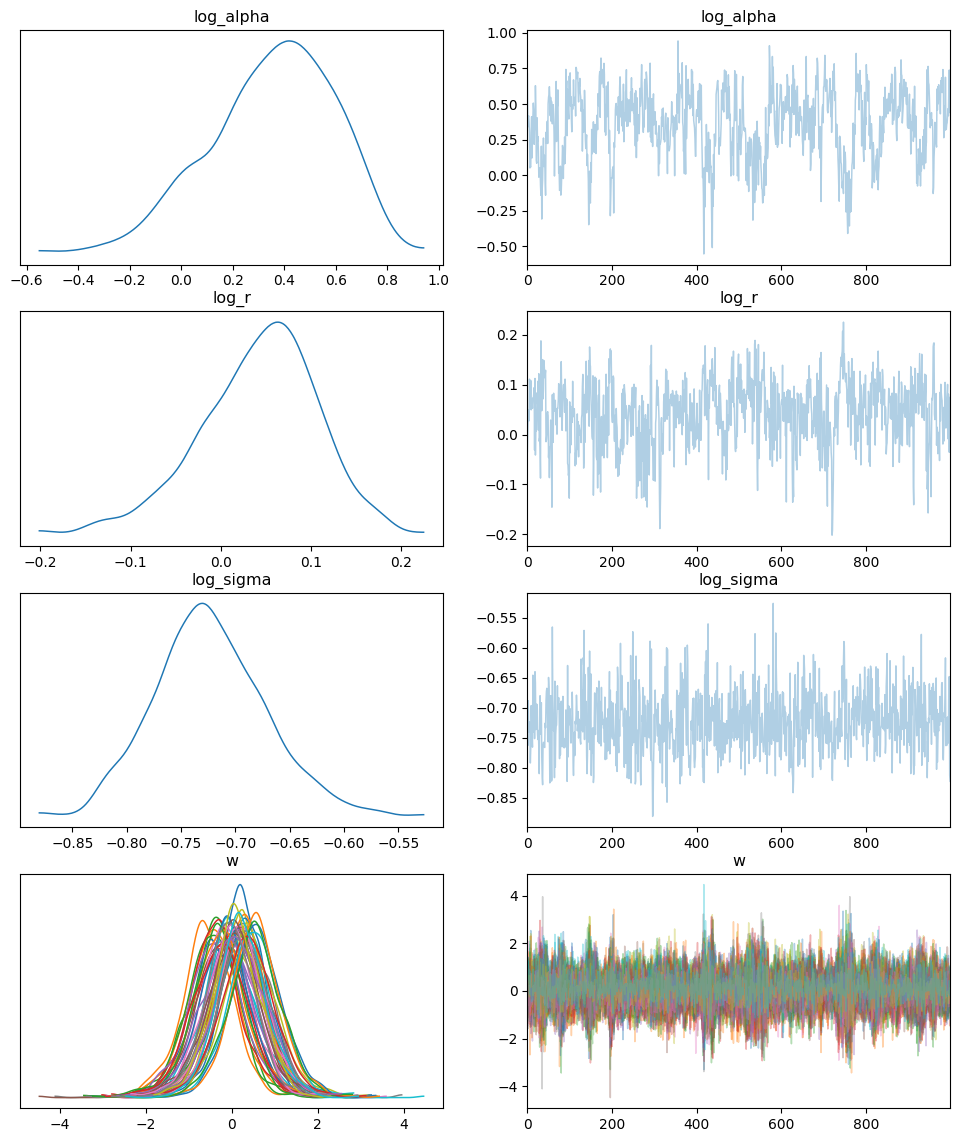

In [10]:
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, compact=True, figsize=(12,14))


## Posterior Predictive Comparison

The final comparison asks how posterior uncertainty should enter a prediction.

The **plug-in predictor** uses the posterior mean weights and posterior mean radius. It is fast and convenient for deployment, but it collapses parameter uncertainty to one representative model.

The **posterior-averaged predictor** evaluates one test curve for every sampled pair of weights and radius, then averages those curves. This is the Bayesian predictive mean and can differ from the plug-in result because averaging is performed after passing parameters through the nonlinear basis construction.

Both predictions are compared with the noiseless reference curve using RMS test error.

Pragmatic RMSE:  1.8700523


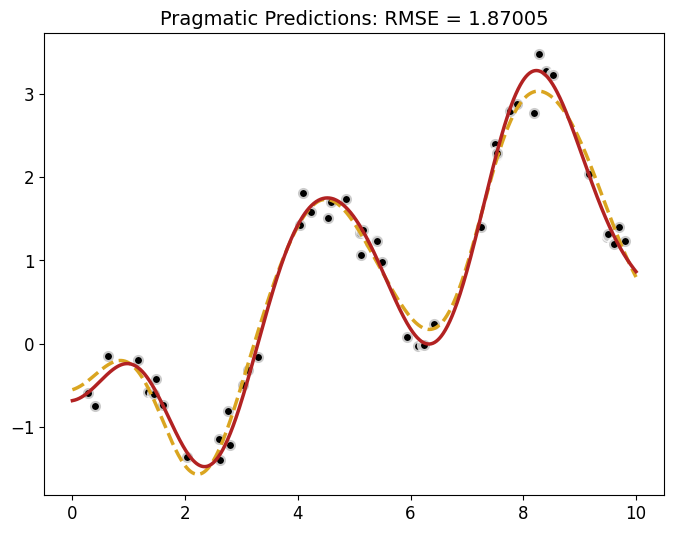

In [11]:
# Pragmatic predictions

w_mean = jnp.mean(posterior_samples['w'], axis=0)

PHI_test_prag = JRBF.evaluate(x_test, r_mean)

y_pred_prag = PHI_test_prag @ w_mean

rmse_prag = setup.error_rms(y_test, y_pred_prag)
print("Pragmatic RMSE: ", rmse_prag)

setup.plot_regression(x_train, y_train, x_test, y_test, y_pred_prag, title=f"Pragmatic Predictions: RMSE = {rmse_prag:.5f}")


Bayesian RMSE:  1.8491257221968365


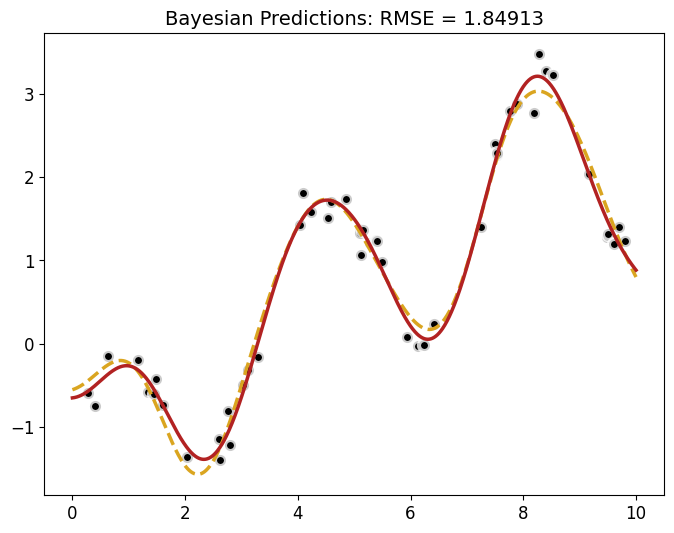

In [12]:
# Bayesian predictions


Bayes_predictions = np.zeros((num_samples, len(x_test)))

for s in range(num_samples):
    log_r = posterior_samples['log_r'][s]
    w = posterior_samples['w'][s]
    r = 10 ** log_r
    PHI_test_bayes = JRBF.evaluate(x_test, r)
    Bayes_predictions[s, :] = PHI_test_bayes @ w

y_pred_bayes = np.mean(Bayes_predictions, axis=0)

rmse_bayes = setup.error_rms(y_test, y_pred_bayes)

print("Bayesian RMSE: ", rmse_bayes)

setup.plot_regression(x_train, y_train, x_test, y_test, y_pred_bayes, title=f"Bayesian Predictions: RMSE = {rmse_bayes:.5f}")
